In [15]:
import os
import json
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

In [5]:
DATASET_FOLDER = r"C:\highway 2"

In [6]:
def get_split_from_path(path):
    parts = os.path.normpath(path).split(os.sep)

    if "Train" in parts:
        return "Train"
    elif "Validation" in parts:
        return "Validation"
    elif "Test" in parts:
        return "Test"
    else:
        return None


def get_attack_type_from_path(path):
    rel = os.path.relpath(path, DATASET_FOLDER)
    first_folder = rel.split(os.sep)[0]

    if first_folder == "InTAS_highway_2":
        return "Benign"
    else:
        return first_folder.replace("InTAS_highway_2_", "")


def parse_vector(value):
    if isinstance(value, list):
        return value

    if isinstance(value, str):
        try:
            return [float(x) for x in value.split(",")]
        except:
            return [np.nan, np.nan, np.nan]

    return [np.nan, np.nan, np.nan]


def get_value(d, key, default=np.nan):
    try:
        return float(d.get(key, default))
    except:
        return default


def extract_msg(msg, attack_type, split_name):
    sender = msg.get("sender", {})
    receiver = msg.get("receiver", {})

    sender_pos = parse_vector(sender.get("pos", np.nan))
    receiver_pos = parse_vector(receiver.get("pos", np.nan))

    sender_pos_noise = parse_vector(sender.get("pos_noise", np.nan))
    receiver_pos_noise = parse_vector(receiver.get("pos_noise", np.nan))

    return {
        "Split": split_name,
        "AttackerType": attack_type,
        "y_binary": int(msg.get("attacker", 0)),

        "rcvTime": get_value(msg, "rcvTime"),
        "sendTime": get_value(msg, "sendTime"),

        "sender_pos_x": sender_pos[0],
        "sender_pos_y": sender_pos[1],

        "receiver_pos_x": receiver_pos[0],
        "receiver_pos_y": receiver_pos[1],

        "sender_pos_noise_x": sender_pos_noise[0],
        "sender_pos_noise_y": sender_pos_noise[1],

        "receiver_pos_noise_x": receiver_pos_noise[0],
        "receiver_pos_noise_y": receiver_pos_noise[1],

        "sender_spd": get_value(sender, "spd"),
        "receiver_spd": get_value(receiver, "spd"),

        "sender_spd_noise": get_value(sender, "spd_noise"),
        "receiver_spd_noise": get_value(receiver, "spd_noise"),

        "sender_acl": get_value(sender, "acl"),
        "receiver_acl": get_value(receiver, "acl"),

        "sender_acl_noise": get_value(sender, "acl_noise"),
        "receiver_acl_noise": get_value(receiver, "acl_noise"),

        "sender_hed": get_value(sender, "hed"),
        "receiver_hed": get_value(receiver, "hed"),

        "sender_hed_noise": get_value(sender, "hed_noise"),
        "receiver_hed_noise": get_value(receiver, "hed_noise"),
    }

In [7]:
rows = []

for root, dirs, files in os.walk(DATASET_FOLDER):

    split_name = get_split_from_path(root)

    if split_name is None:
        continue

    for file in files:

        if not file.endswith(".json"):
            continue

        if "ground" in file.lower():
            continue

        file_path = os.path.join(root, file)
        attack_type = get_attack_type_from_path(file_path)

        try:
            with open(file_path, "r") as f:
                data = json.load(f)

            if isinstance(data, list):
                for msg in data:
                    if isinstance(msg, dict):
                        rows.append(extract_msg(msg, attack_type, split_name))

            elif isinstance(data, dict):
                rows.append(extract_msg(data, attack_type, split_name))

        except Exception as e:
            print("Error loading:", file_path)
            print(e)

df = pd.DataFrame(rows)

print("Loaded shape:", df.shape)

print("\nSplit counts:")
print(df["Split"].value_counts())

print("\nAttack counts:")
print(df["AttackerType"].value_counts())

print("\nBinary counts:")
print(df["y_binary"].value_counts())

Loaded shape: (1733541, 25)

Split counts:
Split
Test          764238
Train         656798
Validation    312505
Name: count, dtype: int64

Attack counts:
AttackerType
trafficCongestionSybil        192294
dosAttack                     142129
Benign                         99937
accelerationMultiplication     99937
constantPositionOffset         99937
constantSpeedOffset            99937
dataReplay                     99937
feignedBraking                 99937
positionMirroring              99937
randomPositionOffset           99937
randomSpeedOffset              99937
reversedHeading                99937
suddenConstantSpeed            99937
suddenStop                     99937
timeDelayAttack                99937
zeroSpeedReport                99937
Name: count, dtype: int64

Binary counts:
y_binary
0    1370938
1     362603
Name: count, dtype: int64


In [8]:
print(df[[
    "sender_pos_x",
    "sender_pos_y",
    "receiver_pos_x",
    "receiver_pos_y",
    "sender_pos_noise_x"
]].head())

print("\nMissing values:")
print(df[[
    "sender_pos_x",
    "sender_pos_y",
    "receiver_pos_x",
    "receiver_pos_y",
    "sender_pos_noise_x"
]].isna().sum())

    sender_pos_x   sender_pos_y  receiver_pos_x  receiver_pos_y  \
0  216246.386379  449957.725496   216165.482233   450006.707818   
1  216398.391252  449863.821227   216165.599129   450006.709654   
2  216390.998673  450049.232157   216165.570940   450006.708489   
3  216161.756066  450023.142608   216165.547702   450006.707787   
4  216246.330586  449957.702949   216175.881636   450000.127932   

   sender_pos_noise_x  
0           -4.014300  
1            4.260615  
2           -3.580029  
3            4.228430  
4           -4.071008  

Missing values:
sender_pos_x          0
sender_pos_y          0
receiver_pos_x        0
receiver_pos_y        0
sender_pos_noise_x    0
dtype: int64


In [9]:
df["pos_noise_abs"] = df["sender_pos_noise_x"].abs()
df["spd_noise_abs"] = df["sender_spd_noise"].abs()
df["acl_noise_abs"] = df["sender_acl_noise"].abs()

df["speed_change"] = (df["sender_spd"] - df["receiver_spd"]).abs()
df["acceleration_change"] = (df["sender_acl"] - df["receiver_acl"]).abs()

df["position_change"] = np.sqrt(
    (df["sender_pos_x"] - df["receiver_pos_x"]) ** 2 +
    (df["sender_pos_y"] - df["receiver_pos_y"]) ** 2
)

In [10]:
feature_cols = [
    "rcvTime",
    "sendTime",

    "sender_pos_x",
    "sender_pos_y",
    "receiver_pos_x",
    "receiver_pos_y",

    "sender_pos_noise_x",
    "sender_pos_noise_y",
    "receiver_pos_noise_x",
    "receiver_pos_noise_y",

    "sender_spd",
    "receiver_spd",
    "sender_spd_noise",
    "receiver_spd_noise",

    "sender_acl",
    "receiver_acl",
    "sender_acl_noise",
    "receiver_acl_noise",

    "sender_hed",
    "receiver_hed",
    "sender_hed_noise",
    "receiver_hed_noise",

    "pos_noise_abs",
    "spd_noise_abs",
    "acl_noise_abs",

    "speed_change",
    "acceleration_change",
    "position_change"
]

for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

feature_cols = [
    col for col in feature_cols
    if df[col].notna().sum() > 0
]

print("Valid features used:")
print(feature_cols)

df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

Valid features used:
['rcvTime', 'sendTime', 'sender_pos_x', 'sender_pos_y', 'receiver_pos_x', 'receiver_pos_y', 'sender_pos_noise_x', 'sender_pos_noise_y', 'receiver_pos_noise_x', 'receiver_pos_noise_y', 'sender_spd', 'receiver_spd', 'sender_spd_noise', 'receiver_spd_noise', 'sender_acl', 'receiver_acl', 'sender_acl_noise', 'receiver_acl_noise', 'sender_hed', 'receiver_hed', 'sender_hed_noise', 'receiver_hed_noise', 'pos_noise_abs', 'spd_noise_abs', 'acl_noise_abs', 'speed_change', 'acceleration_change', 'position_change']


In [11]:
trainval_df = df[
    df["Split"].isin(["Train", "Validation"])
].copy()

X = trainval_df[feature_cols]
y = trainval_df["y_binary"]

print("Train+Validation shape:", X.shape)
print(y.value_counts())

Train+Validation shape: (969303, 28)
y_binary
0    762104
1    207199
Name: count, dtype: int64


In [27]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

y_pred_cv = cross_val_predict(
    pipeline,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

tn, fp, fn, tp = confusion_matrix(y, y_pred_cv).ravel()

fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("CV complete.")

CV complete.


In [29]:
results = pd.DataFrame([{
    "Accuracy": f"{cv_results['test_accuracy'].mean():.2f} ± {cv_results['test_accuracy'].std():.4f}",
    "Precision": f"{cv_results['test_precision'].mean():.2f} ± {cv_results['test_precision'].std():.4f}",
    "Recall": f"{cv_results['test_recall'].mean():.2f} ± {cv_results['test_recall'].std():.4f}",
    "F1": f"{cv_results['test_f1'].mean():.2f} ± {cv_results['test_f1'].std():.4f}",
    "ROC-AUC": f"{cv_results['test_roc_auc'].mean():.2f} ± {cv_results['test_roc_auc'].std():.4f}",
    "FPR": round(fpr, 4),
    "FNR": round(fnr, 4)
}])

results

,Accuracy,Precision,Recall,F1,ROC-AUC,FPR,FNR
0,0.83 ± 0.0011,0.59 ± 0.0027,0.71 ± 0.0020,0.65 ± 0.0012,0.89 ± 0.0007,0.1342,0.2879


In [30]:
results.to_csv("highway2_cv_results_only.csv", index=False)

print("Saved: highway2_cv_results_only.csv")

Saved: highway2_cv_results_only.csv


In [31]:
from xgboost import XGBClassifier

In [32]:
neg = (y == 0).sum()
pos = (y == 1).sum()
scale_pos_weight = neg / pos

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        gamma=0.1,
        reg_lambda=2,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

print("scale_pos_weight:", scale_pos_weight)

cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

y_pred_cv = cross_val_predict(
    pipeline,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

tn, fp, fn, tp = confusion_matrix(y, y_pred_cv).ravel()

fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("CV complete.")

scale_pos_weight: 3.6781258596807898
CV complete.


In [33]:
results = pd.DataFrame([{
    "Accuracy": f"{cv_results['test_accuracy'].mean():.2f} ± {cv_results['test_accuracy'].std():.4f}",
    "Precision": f"{cv_results['test_precision'].mean():.2f} ± {cv_results['test_precision'].std():.4f}",
    "Recall": f"{cv_results['test_recall'].mean():.2f} ± {cv_results['test_recall'].std():.4f}",
    "F1": f"{cv_results['test_f1'].mean():.2f} ± {cv_results['test_f1'].std():.4f}",
    "ROC-AUC": f"{cv_results['test_roc_auc'].mean():.2f} ± {cv_results['test_roc_auc'].std():.4f}",
    "FPR": round(fpr, 4),
    "FNR": round(fnr, 4)
}])

results

,Accuracy,Precision,Recall,F1,ROC-AUC,FPR,FNR
0,0.86 ± 0.0011,0.65 ± 0.0025,0.77 ± 0.0032,0.70 ± 0.0023,0.92 ± 0.0011,0.113,0.2335


In [25]:


pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", GaussianNB(
        var_smoothing=1e-4
    ))
])

cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

y_pred_cv = cross_val_predict(
    pipeline,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

tn, fp, fn, tp = confusion_matrix(y, y_pred_cv).ravel()

fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("CV complete.")

CV complete.


In [26]:
results = pd.DataFrame([{
    "Accuracy": f"{cv_results['test_accuracy'].mean():.2f} ± {cv_results['test_accuracy'].std():.4f}",
    "Precision": f"{cv_results['test_precision'].mean():.2f} ± {cv_results['test_precision'].std():.4f}",
    "Recall": f"{cv_results['test_recall'].mean():.2f} ± {cv_results['test_recall'].std():.4f}",
    "F1": f"{cv_results['test_f1'].mean():.2f} ± {cv_results['test_f1'].std():.4f}",
    "ROC-AUC": f"{cv_results['test_roc_auc'].mean():.2f} ± {cv_results['test_roc_auc'].std():.4f}",
    "FPR": round(fpr, 4),
    "FNR": round(fnr, 4)
}])

results

,Accuracy,Precision,Recall,F1,ROC-AUC,FPR,FNR
0,0.75 ± 0.0006,0.28 ± 0.0015,0.11 ± 0.0017,0.15 ± 0.0018,0.56 ± 0.0005,0.0746,0.8934


In [37]:
from sklearn.linear_model import LogisticRegression

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        C=1,
        solver="lbfgs",
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

print("scale_pos_weight:", scale_pos_weight)

cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

y_pred_cv = cross_val_predict(
    pipeline,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

tn, fp, fn, tp = confusion_matrix(y, y_pred_cv).ravel()

fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("CV complete.")

scale_pos_weight: 3.65878665497243
CV complete.


In [35]:
results = pd.DataFrame([{
    "Accuracy": f"{cv_results['test_accuracy'].mean():.2f} ± {cv_results['test_accuracy'].std():.4f}",
    "Precision": f"{cv_results['test_precision'].mean():.2f} ± {cv_results['test_precision'].std():.4f}",
    "Recall": f"{cv_results['test_recall'].mean():.2f} ± {cv_results['test_recall'].std():.4f}",
    "F1": f"{cv_results['test_f1'].mean():.2f} ± {cv_results['test_f1'].std():.4f}",
    "ROC-AUC": f"{cv_results['test_roc_auc'].mean():.2f} ± {cv_results['test_roc_auc'].std():.4f}",
    "FPR": round(fpr, 4),
    "FNR": round(fnr, 4)
}])

results

,Accuracy,Precision,Recall,F1,ROC-AUC,FPR,FNR
0,0.56 ± 0.0010,0.25 ± 0.0003,0.52 ± 0.0014,0.33 ± 0.0003,0.56 ± 0.0009,0.4301,0.4844


In [40]:
from sklearn.ensemble import ExtraTreesClassifier

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", ExtraTreesClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

print("scale_pos_weight:", scale_pos_weight)

cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

y_pred_cv = cross_val_predict(
    pipeline,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

tn, fp, fn, tp = confusion_matrix(y, y_pred_cv).ravel()

fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("CV complete.")

scale_pos_weight: 3.6781258596807898
CV complete.


In [41]:
results = pd.DataFrame([{
    "Accuracy": f"{cv_results['test_accuracy'].mean():.2f} ± {cv_results['test_accuracy'].std():.4f}",
    "Precision": f"{cv_results['test_precision'].mean():.2f} ± {cv_results['test_precision'].std():.4f}",
    "Recall": f"{cv_results['test_recall'].mean():.2f} ± {cv_results['test_recall'].std():.4f}",
    "F1": f"{cv_results['test_f1'].mean():.2f} ± {cv_results['test_f1'].std():.4f}",
    "ROC-AUC": f"{cv_results['test_roc_auc'].mean():.2f} ± {cv_results['test_roc_auc'].std():.4f}",
    "FPR": round(fpr, 4),
    "FNR": round(fnr, 4)
}])

results

,Accuracy,Precision,Recall,F1,ROC-AUC,FPR,FNR
0,0.87 ± 0.0012,0.69 ± 0.0034,0.68 ± 0.0029,0.69 ± 0.0027,0.89 ± 0.0007,0.0841,0.3174


In [44]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),

    ("model", MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        batch_size=1024,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ))
])

cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

y_pred_cv = cross_val_predict(
    pipeline,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

tn, fp, fn, tp = confusion_matrix(y, y_pred_cv).ravel()

fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("CV complete.")

CV complete.


In [45]:
results = pd.DataFrame([{
    "Accuracy": f"{cv_results['test_accuracy'].mean():.2f} ± {cv_results['test_accuracy'].std():.4f}",
    "Precision": f"{cv_results['test_precision'].mean():.2f} ± {cv_results['test_precision'].std():.4f}",
    "Recall": f"{cv_results['test_recall'].mean():.2f} ± {cv_results['test_recall'].std():.4f}",
    "F1": f"{cv_results['test_f1'].mean():.2f} ± {cv_results['test_f1'].std():.4f}",
    "ROC-AUC": f"{cv_results['test_roc_auc'].mean():.2f} ± {cv_results['test_roc_auc'].std():.4f}",
    "FPR": round(fpr, 4),
    "FNR": round(fnr, 4)
}])

results

,Accuracy,Precision,Recall,F1,ROC-AUC,FPR,FNR
0,0.88 ± 0.0035,0.91 ± 0.0159,0.46 ± 0.0086,0.61 ± 0.0110,0.86 ± 0.0048,0.0125,0.537


In [28]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd
import numpy as np

attack_classes = sorted([
    a for a in df["AttackerType"].unique()
    if a != "Benign"
])

cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

In [52]:
zero_day_rf_results = []

for unseen_attack in attack_classes:

    print("\nUnseen attack:", unseen_attack)

    known_df = df[
        (df["Split"].isin(["Train", "Validation"])) &
        (df["AttackerType"] != unseen_attack)
    ].copy()

    unseen_test_df = df[
        (df["Split"] == "Test") &
        (
            (df["AttackerType"] == "Benign") |
            (df["AttackerType"] == unseen_attack)
        )
    ].copy()

    X_known = known_df[feature_cols]
    y_known = known_df["y_binary"]

    X_unseen_test = unseen_test_df[feature_cols]
    y_unseen_test = unseen_test_df["y_binary"]

    fold_metrics = []

    for fold, (train_idx, _) in enumerate(cv.split(X_known, y_known), start=1):

        print("  Fold:", fold)

        X_train_fold = X_known.iloc[train_idx]
        y_train_fold = y_known.iloc[train_idx]

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=300,
                max_depth=20,
                min_samples_split=10,
                min_samples_leaf=5,
                max_features="sqrt",
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            ))
        ])

        model.fit(X_train_fold, y_train_fold)

        y_pred = model.predict(X_unseen_test)
        y_prob = model.predict_proba(X_unseen_test)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_unseen_test, y_pred).ravel()

        fpr = fp / (fp + tn)
        fnr = fn / (fn + tp)

        fold_metrics.append({
            "Accuracy": accuracy_score(y_unseen_test, y_pred),
            "Precision": precision_score(y_unseen_test, y_pred, zero_division=0),
            "Recall": recall_score(y_unseen_test, y_pred, zero_division=0),
            "F1": f1_score(y_unseen_test, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_unseen_test, y_prob),
            "FPR": fpr,
            "FNR": fnr
        })

    fold_df = pd.DataFrame(fold_metrics)

    zero_day_rf_results.append({
        "Model": "Random Forest",
        "Unseen_Attack": unseen_attack,

        "Accuracy": f"{fold_df['Accuracy'].mean():.2f} ± {fold_df['Accuracy'].std():.4f}",
        "Precision": f"{fold_df['Precision'].mean():.2f} ± {fold_df['Precision'].std():.4f}",
        "Recall": f"{fold_df['Recall'].mean():.2f} ± {fold_df['Recall'].std():.4f}",
        "F1": f"{fold_df['F1'].mean():.2f} ± {fold_df['F1'].std():.4f}",
        "ROC-AUC": f"{fold_df['ROC-AUC'].mean():.2f} ± {fold_df['ROC-AUC'].std():.4f}",
        "FPR": f"{fold_df['FPR'].mean():.4f} ± {fold_df['FPR'].std():.4f}",
        "FNR": f"{fold_df['FNR'].mean():.4f} ± {fold_df['FNR'].std():.4f}",

        "Test_Benign": int((y_unseen_test == 0).sum()),
        "Test_Attack": int((y_unseen_test == 1).sum())
    })


Unseen attack: accelerationMultiplication
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: constantPositionOffset
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: constantSpeedOffset
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: dataReplay
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: dosAttack
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: feignedBraking
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: positionMirroring
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: randomPositionOffset
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: randomSpeedOffset
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: reversedHeading
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: suddenConstantSpeed
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: suddenStop
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: timeDelayAttack
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: trafficCongestionSybil
  Fold:

In [53]:
zero_day_rf_df = pd.DataFrame(zero_day_rf_results)

zero_day_rf_df

,Model,Unseen_Attack,Accuracy,Precision,Recall,F1,ROC-AUC,FPR,FNR,Test_Benign,Test_Attack
0,Random Forest,accelerationMultiplication,0.37 ± 0.0117,0.05 ± 0.0016,0.64 ± 0.0239,0.09 ± 0.0030,0.52 ± 0.0145,0.6435 ± 0.0125,0.3554 ± 0.0239,84411,4107
1,Random Forest,constantPositionOffset,0.57 ± 0.0148,0.10 ± 0.0005,0.41 ± 0.0171,0.16 ± 0.0010,0.52 ± 0.0028,0.4102 ± 0.0183,0.5858 ± 0.0171,79808,8710
2,Random Forest,constantSpeedOffset,0.43 ± 0.0183,0.11 ± 0.0013,0.66 ± 0.0187,0.19 ± 0.0017,0.57 ± 0.0022,0.6013 ± 0.0223,0.3386 ± 0.0187,79618,8900
3,Random Forest,dataReplay,0.46 ± 0.0265,0.11 ± 0.0008,0.62 ± 0.0324,0.19 ± 0.0006,0.55 ± 0.0018,0.5521 ± 0.0329,0.3793 ± 0.0324,79775,8743
4,Random Forest,dosAttack,0.44 ± 0.0127,0.23 ± 0.0051,0.61 ± 0.0182,0.34 ± 0.0071,0.51 ± 0.0083,0.6148 ± 0.0190,0.3915 ± 0.0182,80325,24652
5,Random Forest,feignedBraking,0.43 ± 0.0225,0.05 ± 0.0012,0.73 ± 0.0122,0.09 ± 0.0021,0.63 ± 0.0065,0.5871 ± 0.0238,0.2700 ± 0.0122,85022,3496
6,Random Forest,positionMirroring,0.40 ± 0.0219,0.11 ± 0.0022,0.60 ± 0.0368,0.18 ± 0.0046,0.47 ± 0.0059,0.6212 ± 0.0288,0.4018 ± 0.0368,78900,9618
7,Random Forest,randomPositionOffset,0.56 ± 0.0125,0.11 ± 0.0007,0.51 ± 0.0213,0.18 ± 0.0021,0.55 ± 0.0016,0.4324 ± 0.0159,0.4917 ± 0.0213,80238,8280
8,Random Forest,randomSpeedOffset,0.47 ± 0.0225,0.11 ± 0.0015,0.61 ± 0.0255,0.18 ± 0.0018,0.56 ± 0.0040,0.5410 ± 0.0274,0.3920 ± 0.0255,80124,8394
9,Random Forest,reversedHeading,0.50 ± 0.0108,0.09 ± 0.0038,0.46 ± 0.0161,0.15 ± 0.0061,0.48 ± 0.0135,0.4967 ± 0.0113,0.5445 ± 0.0161,80250,8268


In [54]:
zero_day_xgb_results = []

for unseen_attack in attack_classes:

    print("\nUnseen attack:", unseen_attack)

    known_df = df[
        (df["Split"].isin(["Train", "Validation"])) &
        (df["AttackerType"] != unseen_attack)
    ].copy()

    unseen_test_df = df[
        (df["Split"] == "Test") &
        (
            (df["AttackerType"] == "Benign") |
            (df["AttackerType"] == unseen_attack)
        )
    ].copy()

    X_known = known_df[feature_cols]
    y_known = known_df["y_binary"]

    X_unseen_test = unseen_test_df[feature_cols]
    y_unseen_test = unseen_test_df["y_binary"]

    fold_metrics = []

    for fold, (train_idx, _) in enumerate(cv.split(X_known, y_known), start=1):

        print("  Fold:", fold)

        X_train_fold = X_known.iloc[train_idx]
        y_train_fold = y_known.iloc[train_idx]

        neg = (y_train_fold == 0).sum()
        pos = (y_train_fold == 1).sum()
        scale_pos_weight = neg / pos

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBClassifier(
                n_estimators=500,
                max_depth=8,
                learning_rate=0.05,
                subsample=0.85,
                colsample_bytree=0.85,
                min_child_weight=3,
                gamma=0.1,
                reg_lambda=2,
                scale_pos_weight=scale_pos_weight,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            ))
        ])

        model.fit(X_train_fold, y_train_fold)

        y_pred = model.predict(X_unseen_test)
        y_prob = model.predict_proba(X_unseen_test)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_unseen_test, y_pred).ravel()

        fpr = fp / (fp + tn)
        fnr = fn / (fn + tp)

        fold_metrics.append({
            "Accuracy": accuracy_score(y_unseen_test, y_pred),
            "Precision": precision_score(y_unseen_test, y_pred, zero_division=0),
            "Recall": recall_score(y_unseen_test, y_pred, zero_division=0),
            "F1": f1_score(y_unseen_test, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_unseen_test, y_prob),
            "FPR": fpr,
            "FNR": fnr
        })

    fold_df = pd.DataFrame(fold_metrics)

    zero_day_xgb_results.append({
        "Model": "XGBoost",
        "Unseen_Attack": unseen_attack,

        "Accuracy": f"{fold_df['Accuracy'].mean():.2f} ± {fold_df['Accuracy'].std():.4f}",
        "Precision": f"{fold_df['Precision'].mean():.2f} ± {fold_df['Precision'].std():.4f}",
        "Recall": f"{fold_df['Recall'].mean():.2f} ± {fold_df['Recall'].std():.4f}",
        "F1": f"{fold_df['F1'].mean():.2f} ± {fold_df['F1'].std():.4f}",
        "ROC-AUC": f"{fold_df['ROC-AUC'].mean():.2f} ± {fold_df['ROC-AUC'].std():.4f}",
        "FPR": f"{fold_df['FPR'].mean():.4f} ± {fold_df['FPR'].std():.4f}",
        "FNR": f"{fold_df['FNR'].mean():.4f} ± {fold_df['FNR'].std():.4f}",

        "Test_Benign": int((y_unseen_test == 0).sum()),
        "Test_Attack": int((y_unseen_test == 1).sum())
    })

zero_day_xgb_df = pd.DataFrame(zero_day_xgb_results)
zero_day_xgb_df


Unseen attack: accelerationMultiplication
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: constantPositionOffset
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: constantSpeedOffset
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: dataReplay
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: dosAttack
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: feignedBraking
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: positionMirroring
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: randomPositionOffset
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: randomSpeedOffset
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: reversedHeading
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: suddenConstantSpeed
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: suddenStop
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: timeDelayAttack
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: trafficCongestionSybil
  Fold:

,Model,Unseen_Attack,Accuracy,Precision,Recall,F1,ROC-AUC,FPR,FNR,Test_Benign,Test_Attack
0,XGBoost,accelerationMultiplication,0.06 ± 0.0036,0.05 ± 0.0000,0.99 ± 0.0031,0.09 ± 0.0001,0.60 ± 0.0045,0.9894 ± 0.0039,0.0060 ± 0.0031,84411,4107
1,XGBoost,constantPositionOffset,0.14 ± 0.0102,0.10 ± 0.0006,0.96 ± 0.0115,0.18 ± 0.0011,0.49 ± 0.0093,0.9549 ± 0.0124,0.0406 ± 0.0115,79808,8710
2,XGBoost,constantSpeedOffset,0.12 ± 0.0047,0.10 ± 0.0003,0.98 ± 0.0070,0.18 ± 0.0006,0.57 ± 0.0036,0.9791 ± 0.0058,0.0156 ± 0.0070,79618,8900
3,XGBoost,dataReplay,0.12 ± 0.0011,0.10 ± 0.0004,0.98 ± 0.0038,0.18 ± 0.0008,0.52 ± 0.0034,0.9782 ± 0.0009,0.0187 ± 0.0038,79775,8743
4,XGBoost,dosAttack,0.24 ± 0.0028,0.23 ± 0.0005,0.98 ± 0.0050,0.38 ± 0.0008,0.47 ± 0.0054,0.9850 ± 0.0049,0.0189 ± 0.0050,80325,24652
5,XGBoost,feignedBraking,0.06 ± 0.0054,0.04 ± 0.0002,0.99 ± 0.0021,0.08 ± 0.0004,0.68 ± 0.0179,0.9827 ± 0.0057,0.0065 ± 0.0021,85022,3496
6,XGBoost,positionMirroring,0.12 ± 0.0070,0.11 ± 0.0005,0.98 ± 0.0041,0.20 ± 0.0008,0.49 ± 0.0090,0.9814 ± 0.0083,0.0197 ± 0.0041,78900,9618
7,XGBoost,randomPositionOffset,0.13 ± 0.0168,0.09 ± 0.0007,0.96 ± 0.0128,0.17 ± 0.0009,0.49 ± 0.0068,0.9501 ± 0.0199,0.0445 ± 0.0128,80238,8280
8,XGBoost,randomSpeedOffset,0.10 ± 0.0022,0.10 ± 0.0002,0.99 ± 0.0036,0.17 ± 0.0004,0.54 ± 0.0042,0.9878 ± 0.0028,0.0095 ± 0.0036,80124,8394
9,XGBoost,reversedHeading,0.12 ± 0.0047,0.09 ± 0.0011,0.96 ± 0.0123,0.17 ± 0.0019,0.47 ± 0.0091,0.9698 ± 0.0054,0.0433 ± 0.0123,80250,8268


In [29]:
zero_day_xgb_results = []

for unseen_attack in attack_classes:

    print("\nUnseen attack:", unseen_attack)

    known_df = df[
        (df["Split"].isin(["Train", "Validation"])) &
        (df["AttackerType"] != unseen_attack)
    ].copy()

    unseen_test_df = df[
        (df["Split"] == "Test") &
        (
            (df["AttackerType"] == "Benign") |
            (df["AttackerType"] == unseen_attack)
        )
    ].copy()

    X_known = known_df[feature_cols]
    y_known = known_df["y_binary"]

    X_unseen_test = unseen_test_df[feature_cols]
    y_unseen_test = unseen_test_df["y_binary"]

    fold_metrics = []

    for fold, (train_idx, _) in enumerate(cv.split(X_known, y_known), start=1):

        print("  Fold:", fold)

        X_train_fold = X_known.iloc[train_idx]
        y_train_fold = y_known.iloc[train_idx]

        neg = (y_train_fold == 0).sum()
        pos = (y_train_fold == 1).sum()
        scale_pos_weight = neg / pos

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", GaussianNB(
                var_smoothing=1e-4
            ))
        ])

        model.fit(X_train_fold, y_train_fold)

        y_pred = model.predict(X_unseen_test)
        y_prob = model.predict_proba(X_unseen_test)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_unseen_test, y_pred).ravel()

        fpr = fp / (fp + tn)
        fnr = fn / (fn + tp)

        fold_metrics.append({
            "Accuracy": accuracy_score(y_unseen_test, y_pred),
            "Precision": precision_score(y_unseen_test, y_pred, zero_division=0),
            "Recall": recall_score(y_unseen_test, y_pred, zero_division=0),
            "F1": f1_score(y_unseen_test, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_unseen_test, y_prob),
            "FPR": fpr,
            "FNR": fnr
        })

    fold_df = pd.DataFrame(fold_metrics)

    zero_day_xgb_results.append({
        "Model": "Naive Bayes",
        "Unseen_Attack": unseen_attack,

        "Accuracy": f"{fold_df['Accuracy'].mean():.2f} ± {fold_df['Accuracy'].std():.4f}",
        "Precision": f"{fold_df['Precision'].mean():.2f} ± {fold_df['Precision'].std():.4f}",
        "Recall": f"{fold_df['Recall'].mean():.2f} ± {fold_df['Recall'].std():.4f}",
        "F1": f"{fold_df['F1'].mean():.2f} ± {fold_df['F1'].std():.4f}",
        "ROC-AUC": f"{fold_df['ROC-AUC'].mean():.2f} ± {fold_df['ROC-AUC'].std():.4f}",
        "FPR": f"{fold_df['FPR'].mean():.4f} ± {fold_df['FPR'].std():.4f}",
        "FNR": f"{fold_df['FNR'].mean():.4f} ± {fold_df['FNR'].std():.4f}",

        "Test_Benign": int((y_unseen_test == 0).sum()),
        "Test_Attack": int((y_unseen_test == 1).sum())
    })

zero_day_xgb_df = pd.DataFrame(zero_day_xgb_results)
zero_day_xgb_df


Unseen attack: accelerationMultiplication
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: constantPositionOffset
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: constantSpeedOffset
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: dataReplay
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: dosAttack
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: feignedBraking
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: positionMirroring
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: randomPositionOffset
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: randomSpeedOffset
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: reversedHeading
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: suddenConstantSpeed
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: suddenStop
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: timeDelayAttack
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: trafficCongestionSybil
  Fold:

,Model,Unseen_Attack,Accuracy,Precision,Recall,F1,ROC-AUC,FPR,FNR,Test_Benign,Test_Attack
0,Naive Bayes,accelerationMultiplication,0.09 ± 0.0031,0.05 ± 0.0001,0.96 ± 0.0030,0.09 ± 0.0002,0.66 ± 0.0070,0.9475 ± 0.0034,0.0436 ± 0.0030,84411,4107
1,Naive Bayes,constantPositionOffset,0.16 ± 0.0085,0.10 ± 0.0001,0.90 ± 0.0113,0.17 ± 0.0004,0.48 ± 0.0006,0.9211 ± 0.0107,0.1014 ± 0.0113,79808,8710
2,Naive Bayes,constantSpeedOffset,0.16 ± 0.0057,0.10 ± 0.0002,0.91 ± 0.0096,0.18 ± 0.0006,0.50 ± 0.0011,0.9189 ± 0.0074,0.0932 ± 0.0096,79618,8900
3,Naive Bayes,dataReplay,0.16 ± 0.0082,0.10 ± 0.0002,0.94 ± 0.0084,0.18 ± 0.0002,0.51 ± 0.0011,0.9249 ± 0.0100,0.0556 ± 0.0084,79775,8743
4,Naive Bayes,dosAttack,0.27 ± 0.0004,0.24 ± 0.0002,0.94 ± 0.0012,0.38 ± 0.0003,0.50 ± 0.0007,0.9346 ± 0.0006,0.0628 ± 0.0012,80325,24652
5,Naive Bayes,feignedBraking,0.11 ± 0.0098,0.04 ± 0.0002,0.97 ± 0.0052,0.08 ± 0.0004,0.76 ± 0.0076,0.9277 ± 0.0104,0.0318 ± 0.0052,85022,3496
6,Naive Bayes,positionMirroring,0.16 ± 0.0016,0.11 ± 0.0001,0.96 ± 0.0012,0.20 ± 0.0001,0.51 ± 0.0007,0.9355 ± 0.0020,0.0447 ± 0.0012,78900,9618
7,Naive Bayes,randomPositionOffset,0.19 ± 0.0184,0.09 ± 0.0002,0.84 ± 0.0235,0.16 ± 0.0007,0.48 ± 0.0006,0.8720 ± 0.0227,0.1562 ± 0.0235,80238,8280
8,Naive Bayes,randomSpeedOffset,0.16 ± 0.0047,0.09 ± 0.0002,0.92 ± 0.0070,0.17 ± 0.0004,0.48 ± 0.0006,0.9226 ± 0.0059,0.0822 ± 0.0070,80124,8394
9,Naive Bayes,reversedHeading,0.16 ± 0.0100,0.09 ± 0.0001,0.91 ± 0.0124,0.17 ± 0.0003,0.49 ± 0.0010,0.9168 ± 0.0123,0.0941 ± 0.0124,80250,8268


In [36]:
zero_day_xgb_results = []

for unseen_attack in attack_classes:

    print("\nUnseen attack:", unseen_attack)

    known_df = df[
        (df["Split"].isin(["Train", "Validation"])) &
        (df["AttackerType"] != unseen_attack)
    ].copy()

    unseen_test_df = df[
        (df["Split"] == "Test") &
        (
            (df["AttackerType"] == "Benign") |
            (df["AttackerType"] == unseen_attack)
        )
    ].copy()

    X_known = known_df[feature_cols]
    y_known = known_df["y_binary"]

    X_unseen_test = unseen_test_df[feature_cols]
    y_unseen_test = unseen_test_df["y_binary"]

    fold_metrics = []

    for fold, (train_idx, _) in enumerate(cv.split(X_known, y_known), start=1):

        print("  Fold:", fold)

        X_train_fold = X_known.iloc[train_idx]
        y_train_fold = y_known.iloc[train_idx]

        neg = (y_train_fold == 0).sum()
        pos = (y_train_fold == 1).sum()
        scale_pos_weight = neg / pos

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                penalty="l2",
                C=1,
                solver="lbfgs",
                max_iter=5000,
                class_weight="balanced",
                random_state=42
            ))
        ])

        model.fit(X_train_fold, y_train_fold)

        y_pred = model.predict(X_unseen_test)
        y_prob = model.predict_proba(X_unseen_test)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_unseen_test, y_pred).ravel()

        fpr = fp / (fp + tn)
        fnr = fn / (fn + tp)

        fold_metrics.append({
            "Accuracy": accuracy_score(y_unseen_test, y_pred),
            "Precision": precision_score(y_unseen_test, y_pred, zero_division=0),
            "Recall": recall_score(y_unseen_test, y_pred, zero_division=0),
            "F1": f1_score(y_unseen_test, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_unseen_test, y_prob),
            "FPR": fpr,
            "FNR": fnr
        })

    fold_df = pd.DataFrame(fold_metrics)

    zero_day_xgb_results.append({
        "Model": "LR",
        "Unseen_Attack": unseen_attack,

        "Accuracy": f"{fold_df['Accuracy'].mean():.2f} ± {fold_df['Accuracy'].std():.4f}",
        "Precision": f"{fold_df['Precision'].mean():.2f} ± {fold_df['Precision'].std():.4f}",
        "Recall": f"{fold_df['Recall'].mean():.2f} ± {fold_df['Recall'].std():.4f}",
        "F1": f"{fold_df['F1'].mean():.2f} ± {fold_df['F1'].std():.4f}",
        "ROC-AUC": f"{fold_df['ROC-AUC'].mean():.2f} ± {fold_df['ROC-AUC'].std():.4f}",
        "FPR": f"{fold_df['FPR'].mean():.4f} ± {fold_df['FPR'].std():.4f}",
        "FNR": f"{fold_df['FNR'].mean():.4f} ± {fold_df['FNR'].std():.4f}",

        "Test_Benign": int((y_unseen_test == 0).sum()),
        "Test_Attack": int((y_unseen_test == 1).sum())
    })

zero_day_xgb_df = pd.DataFrame(zero_day_xgb_results)
zero_day_xgb_df


Unseen attack: accelerationMultiplication
  Fold: 1


c:\Users\antho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  Fold: 2


c:\Users\antho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  Fold: 3


...

  Fold: 3


c:\Users\antho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  Fold: 4


c:\Users\antho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Model,Unseen_Attack,Accuracy,Precision,Recall,F1,ROC-AUC,FPR,FNR,Test_Benign,Test_Attack
0,LR,accelerationMultiplication,0.87 ± 0.0139,0.07 ± 0.0032,0.15 ± 0.0156,0.09 ± 0.0013,0.52 ± 0.0030,0.0998 ± 0.0153,0.8521 ± 0.0156,84411,4107
1,LR,constantPositionOffset,0.85 ± 0.0046,0.07 ± 0.0026,0.04 ± 0.0055,0.05 ± 0.0048,0.45 ± 0.0003,0.0636 ± 0.0057,0.9584 ± 0.0055,79808,8710
2,LR,constantSpeedOffset,0.77 ± 0.0114,0.13 ± 0.0016,0.23 ± 0.0182,0.16 ± 0.0046,0.54 ± 0.0005,0.1745 ± 0.0147,0.7698 ± 0.0182,79618,8900
3,LR,dataReplay,0.79 ± 0.0140,0.10 ± 0.0003,0.14 ± 0.0186,0.12 ± 0.0065,0.50 ± 0.0008,0.1340 ± 0.0176,0.8591 ± 0.0186,79775,8743
4,LR,dosAttack,0.61 ± 0.0190,0.25 ± 0.0016,0.33 ± 0.0361,0.28 ± 0.0119,0.51 ± 0.0008,0.3075 ± 0.0359,0.6702 ± 0.0361,80325,24652
5,LR,feignedBraking,0.89 ± 0.0164,0.07 ± 0.0038,0.16 ± 0.0253,0.10 ± 0.0025,0.58 ± 0.0012,0.0845 ± 0.0181,0.8420 ± 0.0253,85022,3496
6,LR,positionMirroring,0.81 ± 0.0130,0.07 ± 0.0012,0.06 ± 0.0108,0.07 ± 0.0067,0.48 ± 0.0003,0.1028 ± 0.0159,0.9370 ± 0.0108,78900,9618
7,LR,randomPositionOffset,0.80 ± 0.0141,0.11 ± 0.0021,0.16 ± 0.0162,0.13 ± 0.0034,0.49 ± 0.0010,0.1394 ± 0.0172,0.8389 ± 0.0162,80238,8280
8,LR,randomSpeedOffset,0.80 ± 0.0108,0.10 ± 0.0008,0.13 ± 0.0134,0.11 ± 0.0049,0.50 ± 0.0011,0.1264 ± 0.0134,0.8698 ± 0.0134,80124,8394
9,LR,reversedHeading,0.84 ± 0.0068,0.06 ± 0.0016,0.04 ± 0.0058,0.05 ± 0.0044,0.45 ± 0.0005,0.0724 ± 0.0081,0.9582 ± 0.0058,80250,8268


In [58]:
zero_day_xgb_results = []

for unseen_attack in attack_classes:

    print("\nUnseen attack:", unseen_attack)

    known_df = df[
        (df["Split"].isin(["Train", "Validation"])) &
        (df["AttackerType"] != unseen_attack)
    ].copy()

    unseen_test_df = df[
        (df["Split"] == "Test") &
        (
            (df["AttackerType"] == "Benign") |
            (df["AttackerType"] == unseen_attack)
        )
    ].copy()

    X_known = known_df[feature_cols]
    y_known = known_df["y_binary"]

    X_unseen_test = unseen_test_df[feature_cols]
    y_unseen_test = unseen_test_df["y_binary"]

    fold_metrics = []

    for fold, (train_idx, _) in enumerate(cv.split(X_known, y_known), start=1):

        print("  Fold:", fold)

        X_train_fold = X_known.iloc[train_idx]
        y_train_fold = y_known.iloc[train_idx]

        neg = (y_train_fold == 0).sum()
        pos = (y_train_fold == 1).sum()
        scale_pos_weight = neg / pos

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", ExtraTreesClassifier(
                n_estimators=400,
                max_depth=None,
                min_samples_split=5,
                min_samples_leaf=2,
                max_features="sqrt",
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            ))
        ])

        model.fit(X_train_fold, y_train_fold)

        y_pred = model.predict(X_unseen_test)
        y_prob = model.predict_proba(X_unseen_test)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_unseen_test, y_pred).ravel()

        fpr = fp / (fp + tn)
        fnr = fn / (fn + tp)

        fold_metrics.append({
            "Accuracy": accuracy_score(y_unseen_test, y_pred),
            "Precision": precision_score(y_unseen_test, y_pred, zero_division=0),
            "Recall": recall_score(y_unseen_test, y_pred, zero_division=0),
            "F1": f1_score(y_unseen_test, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_unseen_test, y_prob),
            "FPR": fpr,
            "FNR": fnr
        })

    fold_df = pd.DataFrame(fold_metrics)

    zero_day_xgb_results.append({
        "Model": "LR",
        "Unseen_Attack": unseen_attack,

        "Accuracy": f"{fold_df['Accuracy'].mean():.2f} ± {fold_df['Accuracy'].std():.4f}",
        "Precision": f"{fold_df['Precision'].mean():.2f} ± {fold_df['Precision'].std():.4f}",
        "Recall": f"{fold_df['Recall'].mean():.2f} ± {fold_df['Recall'].std():.4f}",
        "F1": f"{fold_df['F1'].mean():.2f} ± {fold_df['F1'].std():.4f}",
        "ROC-AUC": f"{fold_df['ROC-AUC'].mean():.2f} ± {fold_df['ROC-AUC'].std():.4f}",
        "FPR": f"{fold_df['FPR'].mean():.4f} ± {fold_df['FPR'].std():.4f}",
        "FNR": f"{fold_df['FNR'].mean():.4f} ± {fold_df['FNR'].std():.4f}",

        "Test_Benign": int((y_unseen_test == 0).sum()),
        "Test_Attack": int((y_unseen_test == 1).sum())
    })

zero_day_xgb_df = pd.DataFrame(zero_day_xgb_results)
zero_day_xgb_df


Unseen attack: accelerationMultiplication
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: constantPositionOffset
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: constantSpeedOffset
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: dataReplay
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: dosAttack
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: feignedBraking
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: positionMirroring
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: randomPositionOffset
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: randomSpeedOffset
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: reversedHeading
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: suddenConstantSpeed
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: suddenStop
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: timeDelayAttack
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4

Unseen attack: trafficCongestionSybil
  Fold:

,Model,Unseen_Attack,Accuracy,Precision,Recall,F1,ROC-AUC,FPR,FNR,Test_Benign,Test_Attack
0,LR,accelerationMultiplication,0.08 ± 0.0017,0.05 ± 0.0001,0.97 ± 0.0031,0.09 ± 0.0002,0.53 ± 0.0056,0.9593 ± 0.0019,0.0317 ± 0.0031,84411,4107
1,LR,constantPositionOffset,0.19 ± 0.0055,0.10 ± 0.0009,0.89 ± 0.0072,0.18 ± 0.0016,0.49 ± 0.0063,0.8843 ± 0.0061,0.1081 ± 0.0072,79808,8710
2,LR,constantSpeedOffset,0.15 ± 0.0036,0.10 ± 0.0005,0.94 ± 0.0050,0.18 ± 0.0008,0.56 ± 0.0045,0.9345 ± 0.0042,0.0560 ± 0.0050,79618,8900
3,LR,dataReplay,0.18 ± 0.0063,0.10 ± 0.0005,0.91 ± 0.0043,0.18 ± 0.0008,0.53 ± 0.0017,0.9018 ± 0.0074,0.0852 ± 0.0043,79775,8743
4,LR,dosAttack,0.27 ± 0.0052,0.23 ± 0.0008,0.93 ± 0.0065,0.37 ± 0.0010,0.50 ± 0.0041,0.9360 ± 0.0085,0.0662 ± 0.0065,80325,24652
5,LR,feignedBraking,0.07 ± 0.0024,0.04 ± 0.0001,0.98 ± 0.0003,0.08 ± 0.0002,0.59 ± 0.0069,0.9658 ± 0.0025,0.0217 ± 0.0003,85022,3496
6,LR,positionMirroring,0.14 ± 0.0037,0.11 ± 0.0008,0.93 ± 0.0104,0.19 ± 0.0014,0.46 ± 0.0087,0.9535 ± 0.0050,0.0690 ± 0.0104,78900,9618
7,LR,randomPositionOffset,0.18 ± 0.0066,0.09 ± 0.0004,0.91 ± 0.0096,0.17 ± 0.0007,0.51 ± 0.0079,0.9001 ± 0.0081,0.0890 ± 0.0096,80238,8280
8,LR,randomSpeedOffset,0.15 ± 0.0042,0.10 ± 0.0005,0.96 ± 0.0059,0.18 ± 0.0009,0.55 ± 0.0086,0.9400 ± 0.0050,0.0407 ± 0.0059,80124,8394
9,LR,reversedHeading,0.18 ± 0.0036,0.09 ± 0.0008,0.88 ± 0.0092,0.17 ± 0.0015,0.48 ± 0.0113,0.8874 ± 0.0042,0.1172 ± 0.0092,80250,8268


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

zero_day_xgb_results = []

for unseen_attack in attack_classes:

    print("\nUnseen attack:", unseen_attack)

    known_df = df[
        (df["Split"].isin(["Train", "Validation"])) &
        (df["AttackerType"] != unseen_attack)
    ].copy()

    unseen_test_df = df[
        (df["Split"] == "Test") &
        (
            (df["AttackerType"] == "Benign") |
            (df["AttackerType"] == unseen_attack)
        )
    ].copy()

    X_known = known_df[feature_cols]
    y_known = known_df["y_binary"]

    X_unseen_test = unseen_test_df[feature_cols]
    y_unseen_test = unseen_test_df["y_binary"]

    fold_metrics = []

    for fold, (train_idx, _) in enumerate(cv.split(X_known, y_known), start=1):

        print("  Fold:", fold)

        X_train_fold = X_known.iloc[train_idx]
        y_train_fold = y_known.iloc[train_idx]

        neg = (y_train_fold == 0).sum()
        pos = (y_train_fold == 1).sum()
        scale_pos_weight = neg / pos

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                hidden_layer_sizes=(256, 128, 64),
                activation="relu",
                solver="adam",
                alpha=0.0001,
                batch_size=1024,
                learning_rate_init=0.001,
                max_iter=300,
                early_stopping=True,
                validation_fraction=0.1,
                random_state=42
            ))
        ])

        model.fit(X_train_fold, y_train_fold)

        y_pred = model.predict(X_unseen_test)
        y_prob = model.predict_proba(X_unseen_test)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_unseen_test, y_pred).ravel()

        fpr = fp / (fp + tn)
        fnr = fn / (fn + tp)

        fold_metrics.append({
            "Accuracy": accuracy_score(y_unseen_test, y_pred),
            "Precision": precision_score(y_unseen_test, y_pred, zero_division=0),
            "Recall": recall_score(y_unseen_test, y_pred, zero_division=0),
            "F1": f1_score(y_unseen_test, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_unseen_test, y_prob),
            "FPR": fpr,
            "FNR": fnr
        })

    fold_df = pd.DataFrame(fold_metrics)

    zero_day_xgb_results.append({
        "Model": "MLP",
        "Unseen_Attack": unseen_attack,

        "Accuracy": f"{fold_df['Accuracy'].mean():.2f} ± {fold_df['Accuracy'].std():.4f}",
        "Precision": f"{fold_df['Precision'].mean():.2f} ± {fold_df['Precision'].std():.4f}",
        "Recall": f"{fold_df['Recall'].mean():.2f} ± {fold_df['Recall'].std():.4f}",
        "F1": f"{fold_df['F1'].mean():.2f} ± {fold_df['F1'].std():.4f}",
        "ROC-AUC": f"{fold_df['ROC-AUC'].mean():.2f} ± {fold_df['ROC-AUC'].std():.4f}",
        "FPR": f"{fold_df['FPR'].mean():.4f} ± {fold_df['FPR'].std():.4f}",
        "FNR": f"{fold_df['FNR'].mean():.4f} ± {fold_df['FNR'].std():.4f}",

        "Test_Benign": int((y_unseen_test == 0).sum()),
        "Test_Attack": int((y_unseen_test == 1).sum())
    })

zero_day_xgb_df = pd.DataFrame(zero_day_xgb_results)
zero_day_xgb_df


Unseen attack: accelerationMultiplication
  Fold: 1
  Fold: 2
  Fold: 3
  Fold: 4


c:\Users\antho\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")



Unseen attack: constantPositionOffset
  Fold: 1


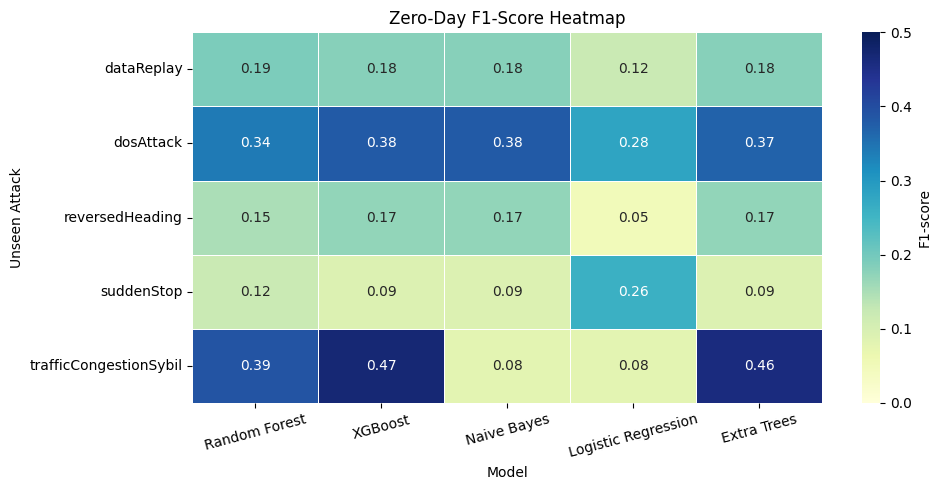

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# UPDATED F1 DATA FROM SELECTED ZERO-DAY TABLE
# ============================================================

data = [
    # Random Forest
    ["Random Forest", "dataReplay", 0.19],
    ["Random Forest", "dosAttack", 0.34],
    ["Random Forest", "reversedHeading", 0.15],
    ["Random Forest", "suddenStop", 0.12],
    ["Random Forest", "trafficCongestionSybil", 0.39],

    # XGBoost
    ["XGBoost", "dataReplay", 0.18],
    ["XGBoost", "dosAttack", 0.38],
    ["XGBoost", "reversedHeading", 0.17],
    ["XGBoost", "suddenStop", 0.09],
    ["XGBoost", "trafficCongestionSybil", 0.47],

    # Naive Bayes
    ["Naive Bayes", "dataReplay", 0.18],
    ["Naive Bayes", "dosAttack", 0.38],
    ["Naive Bayes", "reversedHeading", 0.17],
    ["Naive Bayes", "suddenStop", 0.09],
    ["Naive Bayes", "trafficCongestionSybil", 0.08],

    # Logistic Regression
    ["Logistic Regression", "dataReplay", 0.12],
    ["Logistic Regression", "dosAttack", 0.28],
    ["Logistic Regression", "reversedHeading", 0.05],
    ["Logistic Regression", "suddenStop", 0.26],
    ["Logistic Regression", "trafficCongestionSybil", 0.08],

    # Extra Trees
    ["Extra Trees", "dataReplay", 0.18],
    ["Extra Trees", "dosAttack", 0.37],
    ["Extra Trees", "reversedHeading", 0.17],
    ["Extra Trees", "suddenStop", 0.09],
    ["Extra Trees", "trafficCongestionSybil", 0.46],
]

df_heat = pd.DataFrame(
    data,
    columns=["Model", "Unseen Attack", "F1"]
)

# ============================================================
# PIVOT TABLE
# ============================================================

heatmap_data = df_heat.pivot(
    index="Unseen Attack",
    columns="Model",
    values="F1"
)

# ============================================================
# COLUMN ORDER
# ============================================================

heatmap_data = heatmap_data[
    [
        "Random Forest",
        "XGBoost",
        "Naive Bayes",
        "Logistic Regression",
        "Extra Trees"
    ]
]

# ============================================================
# ROW ORDER
# ============================================================

heatmap_data = heatmap_data.reindex([
    "dataReplay",
    "dosAttack",
    "reversedHeading",
    "suddenStop",
    "trafficCongestionSybil"
])

# ============================================================
# PLOT HEATMAP
# ============================================================

plt.figure(figsize=(10, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "F1-score"},
    vmin=0,
    vmax=0.5
)

plt.title("Zero-Day F1-Score Heatmap")
plt.xlabel("Model")
plt.ylabel("Unseen Attack")

plt.xticks(rotation=15)
plt.yticks(rotation=0)

plt.tight_layout()

# ============================================================
# SAVE FIGURES
# ============================================================

plt.savefig(
    "zero_day_f1_heatmap.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "zero_day_f1_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    r"C:\Users\antho\Desktop\zero_day_f1_heatmap.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

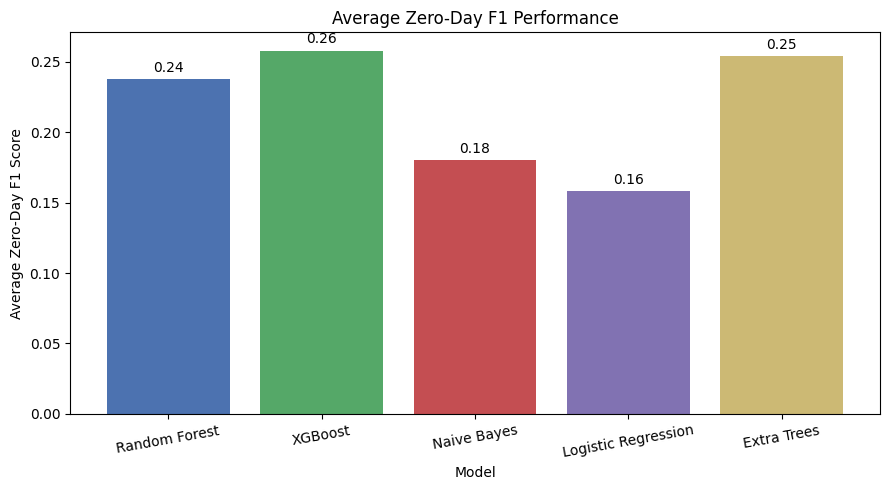

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# UPDATED AVERAGE F1 SCORES
# ============================================================

models = [
    "Random Forest",
    "XGBoost",
    "Naive Bayes",
    "Logistic Regression",
    "Extra Trees"
]

avg_f1 = [
    (0.19 + 0.34 + 0.15 + 0.12 + 0.39) / 5,
    (0.18 + 0.38 + 0.17 + 0.09 + 0.47) / 5,
    (0.18 + 0.38 + 0.17 + 0.09 + 0.08) / 5,
    (0.12 + 0.28 + 0.05 + 0.26 + 0.08) / 5,
    (0.18 + 0.37 + 0.17 + 0.09 + 0.46) / 5
]

# ============================================================
# BAR COLORS
# ============================================================

colors = [
    "#4C72B0",   # Blue
    "#55A868",   # Green
    "#C44E52",   # Red
    "#8172B2",   # Purple
    "#CCB974"    # Gold
]

# ============================================================
# BAR CHART
# ============================================================

plt.figure(figsize=(9,5))

bars = plt.bar(
    models,
    avg_f1,
    color=colors
)

plt.ylabel("Average Zero-Day F1 Score")
plt.xlabel("Model")
plt.title("Average Zero-Day F1 Performance")

# ============================================================
# SHOW VALUES ABOVE BARS
# ============================================================

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.2f}",
        ha='center',
        fontsize=10
    )

# ============================================================
# ROTATE LABELS
# ============================================================

plt.xticks(rotation=10)

# ============================================================
# SAVE FIGURES
# ============================================================

plt.tight_layout()

plt.savefig(
    "average_zero_day_f1.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "average_zero_day_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    r"C:\Users\antho\Desktop\average_zero_day_f1.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()